In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import pylab
from PIL import Image
from math import e
import astropy.io.fits as pf
from astropy.io import fits
#from scipy import signal

In [2]:
CGPS = fits.open('/home/aordog/DATA/CGPS_FITS_files/CGPS_C21.fits')
hdr = CGPS[0].header
data_full = CGPS[0].data[0,0]
print(data_full.shape)
print(hdr['CDELT1'])

CGPS2 = fits.open('/home/aordog/DATA/CGPS_FITS_files/all_stokesi_allbands9.fits')
hdr2 = CGPS2[0].header
data_ST = CGPS2[0].data#[0,0]
print(data_ST.shape)
print(hdr2['CDELT1'])

(4224, 28247)
-0.0049999994
(1825, 29025)
-0.0049999994


In [7]:
def gf(mu,fwhm,x):
    return np.exp(-4*np.log(2)*((x-mu)**2)/fwhm**2)
    

def regular_image(data,j0,i0,nxy,taper=False,taper_width=50,*args,**kwargs):

    image = data[j0:j0+nxy,i0:i0+nxy]

    dxy = np.round(hdr['CDELT2'],5)
    pix0 = int((nxy-1)/2)
    widxy = nxy*dxy
    
    if taper:      
        x, y = np.meshgrid(np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy), 
                       np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy))
        r = np.sqrt(x**2+y**2)
        
        taper = gf(nxy/2-taper_width,taper_width,r)
        taper[np.where(r<=nxy/2-taper_width)] = 1
        image = image*taper

    print('Width of each pixel: '+str(dxy)+ ' deg.')
    print('Number of x and y pixels: '+str(nxy))
    print('Central pixel index: '+str(pix0))
    print('Width of image: '+str(widxy)+' deg.')
    
    return image,dxy,pix0,widxy


def padded_image(data,j0,i0,nxy,taper=False,taper_width=50,*args,**kwargs):

    image_small = data[j0:j0+nxy,i0:i0+nxy]

    dxy = np.round(hdr['CDELT2'],5)
    pix0 = int((nxy-1)/2)+int((nxy+1)/2)
    widxy = nxy*dxy
    
    if taper:      
        x, y = np.meshgrid(np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy), 
                       np.linspace(-(nxy-1)/2,(nxy-1)/2,nxy))
        r = np.sqrt(x**2+y**2)
        
        taper = gf(nxy/2-taper_width,taper_width,r)
        taper[np.where(r<=nxy/2-taper_width)] = 1
        image_small = image_small*taper
        plt.plot(taper[511,:])
        
    image = np.zeros([2*nxy+1,2*nxy+1])
    image[:,:] = np.nanmean(image_small)
    image[int((nxy+1)/2):int((nxy+1)/2)+nxy,int((nxy+1)/2):int((nxy+1)/2)+nxy] = image_small

    print('Width of each pixel: '+str(dxy)+ ' deg.')
    print('Number of x and y pixels: '+str(nxy))
    print('Central pixel index: '+str(pix0))
    print('Width of image: '+str(widxy)+' deg.')
    
    return image,dxy,pix0,widxy

Width of each pixel: 0.005 deg.
Number of x and y pixels: 1023
Central pixel index: 511
Width of image: 5.115 deg.

Width of each pixel: 0.005 deg.
Number of x and y pixels: 1023
Central pixel index: 511
Width of image: 5.115 deg.


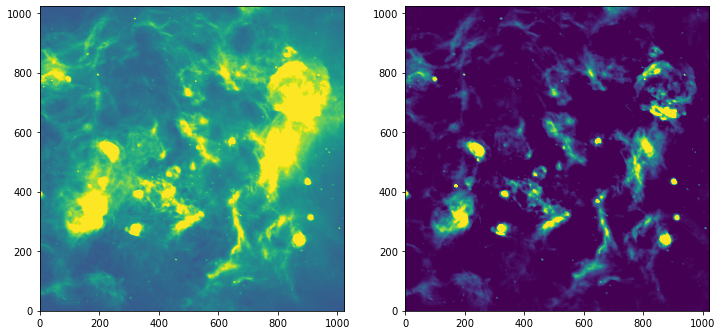

In [11]:
image_full,dxy,pix0,widxy = regular_image(data_full,400,22100,1023)
print('')
image_ST_true,dxy,pix0,widxy = regular_image(data_ST,400,22555,1023)

fig,ax = plt.subplots(1,2,figsize=(12,6)) 
ax[0].imshow(image_full,origin='lower',vmin=0,vmax=30)
ax[1].imshow(image_ST_true,origin='lower',vmin=0,vmax=0.2)

In [51]:
def ST_observe(image,dxy,pix0,R=6,*arg,**kwargs):
    
    image_FFT = np.fft.fft2(image)
    image_FFT_shift = np.fft.fftshift(image_FFT)

    uv_freq = np.fft.fftshift(np.fft.fftfreq(image.shape[0]))/dxy
    uv_m = uv_freq*(3e8/1420e6)*180/(np.pi**2)
    #print(uv_m) # Units of 1/deg

    xuv, yuv = np.meshgrid(uv_m, uv_m)
    ruv = np.sqrt(xuv**2+yuv**2)

    mask = np.ones_like(image)
    npix1 = 2*int(np.round(R*np.diff(uv_m)[0],0))
    npix = npix1*2+1
    window1d = np.hanning(npix)
    window2d = 1-np.outer(window1d,window1d)
    mask[pix0-npix1:pix0+npix1+1,pix0-npix1:pix0+npix1+1] = window2d
    
    image_FFT_shift = image_FFT_shift*mask
    image_ST = np.fft.ifft2(np.fft.ifftshift(image_FFT_shift))
    
    return image_ST, image_FFT_shift, mask, uv_m

def SA_observe(image,dxy,pix0,R=9,*arg,**kwargs):
    
    image_FFT = np.fft.fft2(image)
    image_FFT_shift = np.fft.fftshift(image_FFT)

    uv_freq = np.fft.fftshift(np.fft.fftfreq(image.shape[0]))/dxy
    uv_m = uv_freq*(3e8/1420e6)*180/(np.pi**2)
    #print(uv_m) # Units of 1/deg

    xuv, yuv = np.meshgrid(uv_m, uv_m)
    ruv = np.sqrt(xuv**2+yuv**2)

    mask = np.zeros_like(image)
    npix1 = 2*int(np.round(R*np.diff(uv_m)[0],0))
    npix = npix1*2+1
    window1d = np.hanning(npix)
    window2d = np.outer(window1d,window1d)
    mask[pix0-npix1:pix0+npix1+1,pix0-npix1:pix0+npix1+1] = window2d
    
    image_FFT_shift = image_FFT_shift*mask
    image_SA = np.fft.ifft2(np.fft.ifftshift(image_FFT_shift))
    
    return image_SA, image_FFT_shift, mask, uv_m

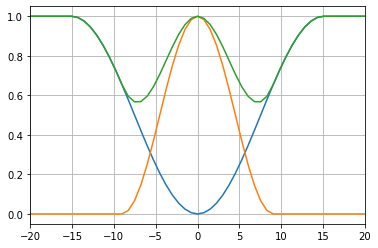

In [87]:
image_ST,FFT_ST,mask_ST, uv_m_ST = ST_observe(image_full,dxy,pix0,R=13)
image_SA,FFT_SA,mask_SA, uv_m_SA = SA_observe(image_full,dxy,pix0,R=8)
plt.plot(uv_m_ST,mask_ST[pix0,:])
plt.plot(uv_m_SA,mask_SA[pix0,:])
plt.plot(uv_m_ST,mask_ST[pix0,:]+mask_SA[pix0,:])
plt.xlim(-20,20)
plt.grid()

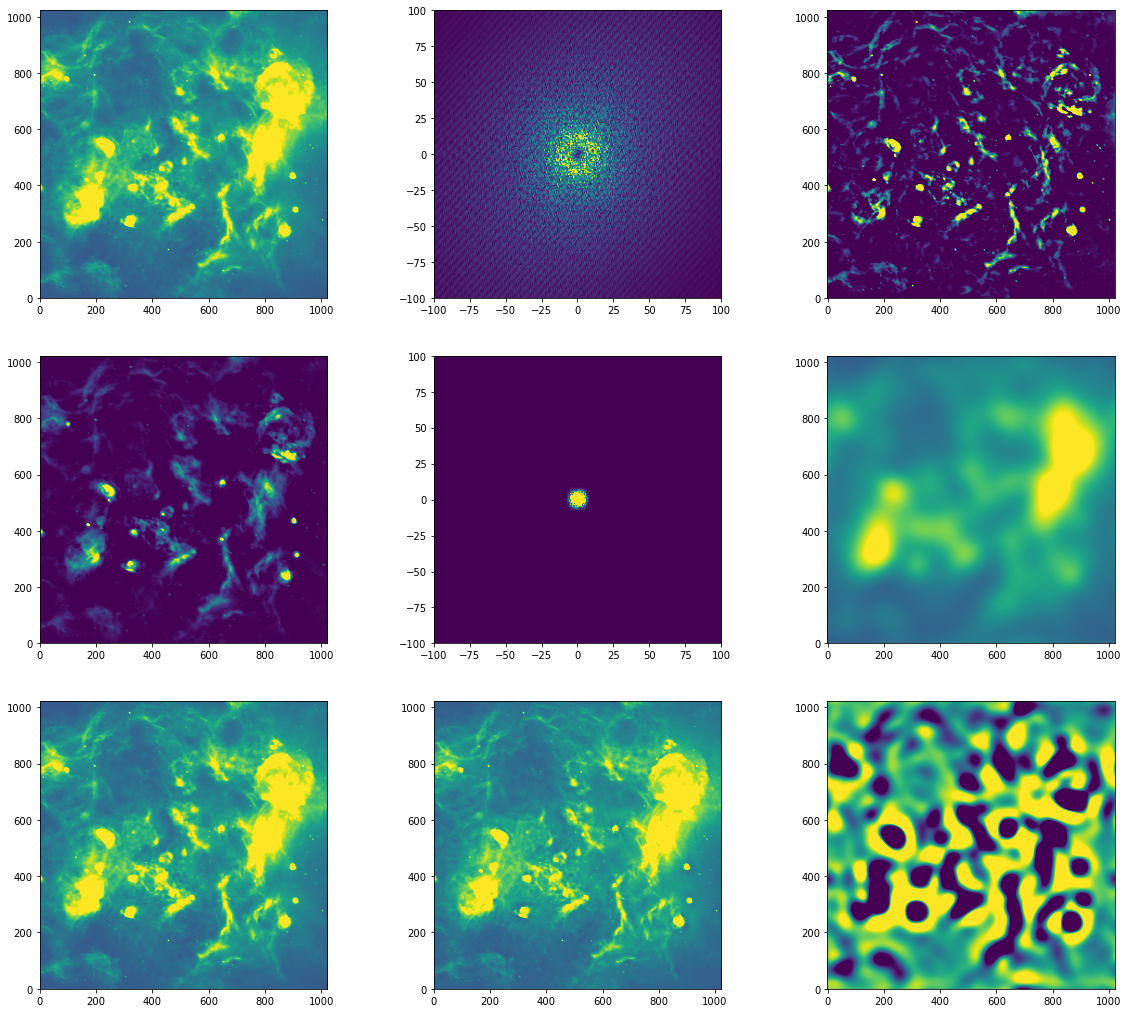

In [88]:
fig,ax = plt.subplots(3,3,figsize=(20,18)) 
ax[0,0].imshow(image_full,origin='lower',vmin=0,vmax=30)
ax[0,1].imshow(abs(FFT_ST),origin='lower',vmin=0,vmax=1e5,
             extent=[uv_m_ST[0],uv_m_ST[-1],uv_m_ST[0],uv_m_ST[-1]])
ax[0,2].imshow(image_ST.real,origin='lower',vmin=0,vmax=10)
ax[0,1].set_xlim(-100,100)
ax[0,1].set_ylim(-100,100)

ax[1,0].imshow(image_ST_true,origin='lower',vmin=0,vmax=0.3)
ax[1,1].imshow(abs(FFT_SA),origin='lower',vmin=0,vmax=1e5,
             extent=[uv_m_SA[0],uv_m_SA[-1],uv_m_SA[0],uv_m_SA[-1]])
ax[1,2].imshow(image_SA.real,origin='lower',vmin=0,vmax=30)
ax[1,1].set_xlim(-100,100)
ax[1,1].set_ylim(-100,100)

ax[2,0].imshow(image_full,origin='lower',vmin=0,vmax=30)
ax[2,1].imshow(image_ST.real+image_SA.real,origin='lower',vmin=0,vmax=30)
ax[2,2].imshow(image_ST.real+image_SA.real-image_full,origin='lower',vmin=-1,vmax=1)